<a href="https://colab.research.google.com/github/Geonus99/AI_26/blob/main/AI_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# 인공신경망을 구성하는 절차
# 1. 더미데이터 준비
# 2. 훈련용, 검증용, 테스트용으로 나눔
# 3. 심층을 만듬(dense)
# 4. model에 적용(Sequential)
# 5. 컴파일 진행(최적화기법을 적용 : adam)
# 6. fit(훈련)
# 7. evaluate(검증)
# 8. predict(예측)

In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [17]:
print("훈련데이터 : ",train_scaled.shape, train_target.shape)
print("테스트데이터 : ",test_input.shape, test_target.shape)
print("검증데이터 : ", val_scaled.shape, val_target.shape)

훈련데이터 :  (48000, 28, 28) (48000,)
테스트데이터 :  (10000, 28, 28) (10000,)
검증데이터 :  (12000, 28, 28) (12000,)


In [18]:
def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28,28)))
  model.add(keras.layers.Dense(100, activation='relu'))

  if a_layer:
    model.add(a_layer)
  model.add(keras.layers.Dense(10, activation='softmax'))
  return model
model = model_fn()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
history = model.fit(train_scaled, train_target, epochs=5, verbose=2)

Epoch 1/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8112 - loss: 0.5311
Epoch 2/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8586 - loss: 0.3903
Epoch 3/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8729 - loss: 0.3523
Epoch 4/5
1500/1500 - 4s - 2ms/step - accuracy: 0.8810 - loss: 0.3306
Epoch 5/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8873 - loss: 0.3141


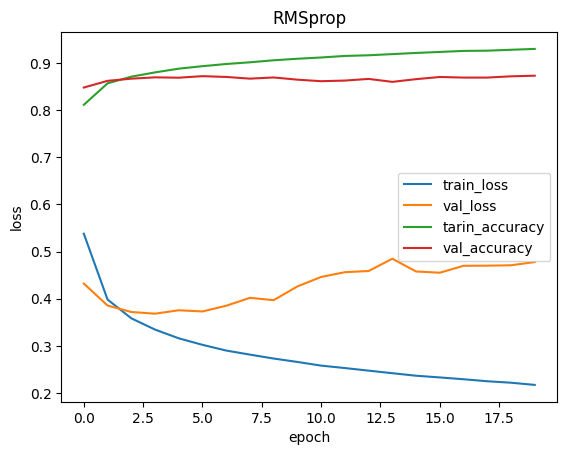

In [26]:
model = model_fn()
model.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_RMS = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history_RMS.history['loss'])
plt.plot(history_RMS.history['val_loss'])
plt.plot(history_RMS.history['accuracy'])
plt.plot(history_RMS.history['val_accuracy'])
plt.title('RMSprop')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','tarin_accuracy', 'val_accuracy'])
plt.show()

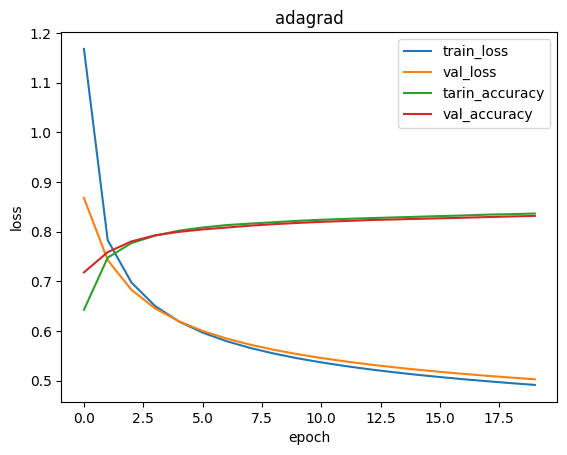

In [27]:
model = model_fn()
model.compile(optimizer='adagrad', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_ada = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history_ada.history['loss'])
plt.plot(history_ada.history['val_loss'])
plt.plot(history_ada.history['accuracy'])
plt.plot(history_ada.history['val_accuracy'])
plt.title('adagrad')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','tarin_accuracy', 'val_accuracy'])
plt.show()

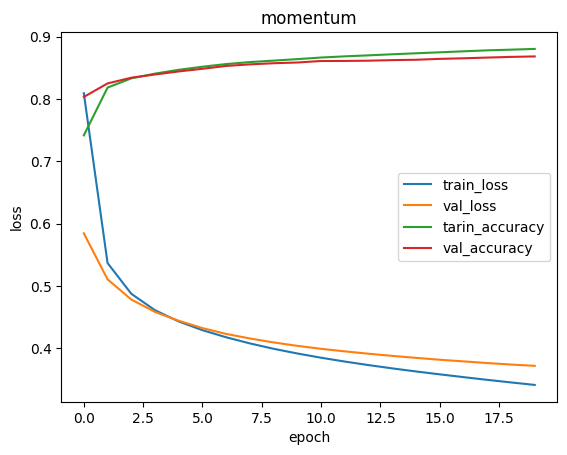

In [54]:
model = model_fn()
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_momentum = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history_momentum.history['loss'])
plt.plot(history_momentum.history['val_loss'])
plt.plot(history_momentum.history['accuracy'])
plt.plot(history_momentum.history['val_accuracy'])
plt.title('momentum')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','tarin_accuracy', 'val_accuracy'])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


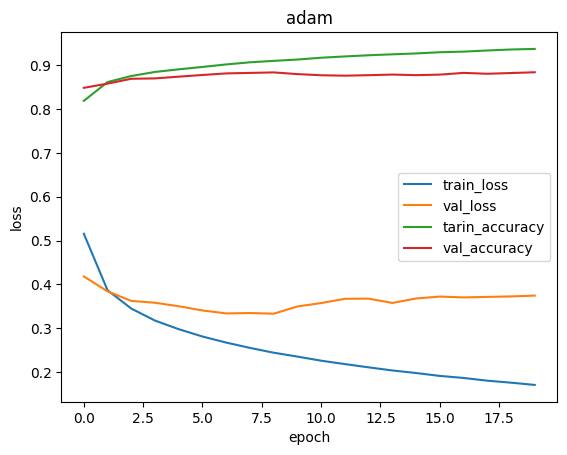

In [56]:
model = model_fn()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_adam = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
plt.plot(history_adam.history['loss'])
plt.plot(history_adam.history['val_loss'])
plt.plot(history_adam.history['accuracy'])
plt.plot(history_adam.history['val_accuracy'])
plt.title('adam')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','tarin_accuracy', 'val_accuracy'])
plt.show()

In [71]:
model = model_fn(keras.layers.Dropout(0.3))

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

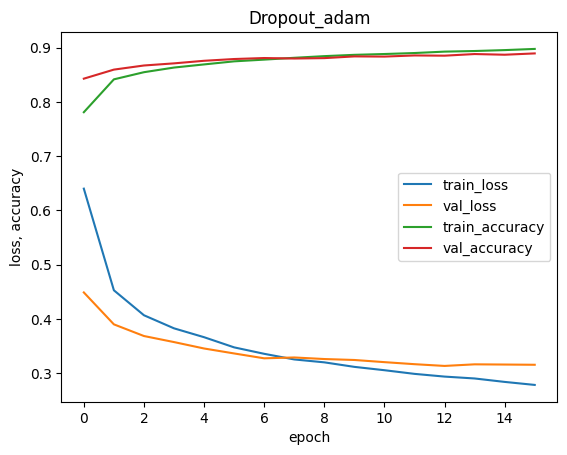

In [72]:
adam_custom = keras.optimizers.Adam(learning_rate=0.0005)

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)
model.compile(optimizer=adam_custom, loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=40, verbose=0,
                    validation_data=(val_scaled, val_target),
                    callbacks=[early_stopping_cb])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Dropout_adam')
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

In [73]:
model.save('model_op_adam.keras')
model.save_weights('model-op_adam.weights.h5')

In [74]:
model = keras.models.load_model('model_op_adam.keras')
test_scaled = test_input / 255.0
evl = model.evaluate(test_scaled, test_target)
print(f"테스트 정확도 : {evl[1]:.4f}")
print(f"테스트 로스 : {evl[0]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8785 - loss: 0.3430
테스트 정확도 : 0.8768
테스트 로스 : 0.3454


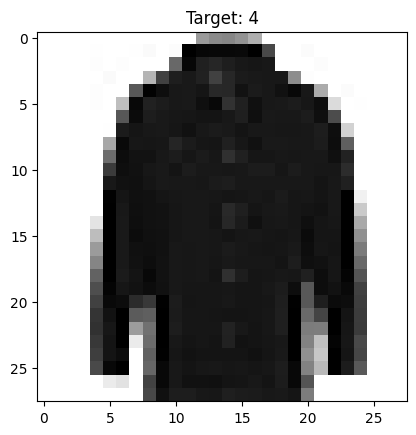

In [75]:
plt.imshow(test_scaled[14], cmap='gray_r')
plt.title(f"Target: {test_target[14]}")
plt.show()

In [43]:
preds = model.predict(test_scaled[14:15])
predicted_class = np.argmax(preds)
print(f"모델이 예측한 정답 번호: {predicted_class}")

print(f"진짜 정답 번호: {test_target[14]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
모델이 예측한 정답 번호: 4
진짜 정답 번호: 4
